> Module: Deep learning<br>
> Lab: 2<br>
> Name: Chun-Yuan Chen<br>

# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [1]:
# Display matplotlib plots inline, meaning the plots will appear directly below the code cell that produces them.
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

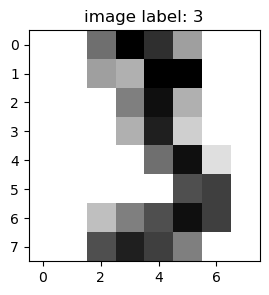

In [2]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r, interpolation='nearest') 
# gray_r: white represents low values, black represents high values.
# nearest: each pixel is shown as a solid square, no smoothing.
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [3]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32') # Converts the digit image data (flattened 8×8 images, a 64-element vector) into a NumPy array.
target = np.asarray(digits.target, dtype='int32') # Converts the digit labels (0, 1, ..., 9) into a NumPy array of integers.

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

> CYC notes:<br>
> Softmax function: turns raw scores into probabilities, which add up to 1. So, can say like the model is 88% confident this is digit 6.<br>
> NNL: measures how bad the predictions are, which the value lower is better.  

In [4]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y] # Creates an identity matrix of shape, each row is a one-hot vector for a class.

In [5]:
# Return a one-hot encoded vector for the class label 3 out of 10 possible classes (0 to 9).
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [6]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [7]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True) # Finds the max value in each row (or vector) of X.
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation.
    return exp / np.sum(exp, axis=-1, keepdims=True) # Normalizes the exponentials so they sum to 1.

> CYC notes:<br>
> The softmax function is used in machine learning to convert a vector of raw scores (logits) into probabilities.<br>
> axis=0: goes down the rows (vertical); axis=1: goes across the columns (horizontal); axis=-1: the last axis.<br>

Let's make sure that this works one vector at a time (and check that the components sum to one):

In [8]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [9]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [10]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [11]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [12]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [13]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15) # Ensures no value in Y_pred is exactly 0 or 1. log(0) is undefined, and log(1)=0.

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [14]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [15]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [16]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers b/w -0.1 and 0.1
        self.W = np.random.uniform(size=(input_size, output_size), high=0.1, low=-0.1) # Each input feature connects to each output class.
        self.b = np.random.uniform(size=output_size, high=0.1, low=-0.1) # A bias term for each output class.
        
        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X): # Forward pass
        # Compute the linear combination of the input and weights: Z = XW + b
        Z =  np.dot(X, self.W) + self.b
        return softmax(Z) # Applies the softmax function to turn raw scores into probabilities
    
    def predict(self, X): # Class prediction
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return np.argmax(self.forward(X)) # If X is a single sample (1D), return the index of the highest probability.
        else:
            return np.argmax(self.forward(X), axis=1) # If X is a 2D, return the index of the highest probability for each row.
            
    def loss(self, X, y): # Compute NLL loss
        # Compute the negative log likelihood over the data provided
        y_pred = self.forward(X) # Get predicted probabilities from the model.
        y_onehot = one_hot(self.output_size, y.astype(int)) # Convert labels to one-hot encoding.
        log_likelihood = -np.sum(y_onehot * np.log(y_pred + 1e-9))
        return log_likelihood / X.shape[0] # Average the loss over the batch

    def grad_loss(self, X, y_true, y_pred): # Compute gradients
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
    
        # Gradient with respect to weights
        grad_W = np.dot(X.T, (y_pred - y_true))
    
        # Gradient with respect to biases
        grad_b = np.sum(y_pred - y_true, axis=0)
    
        return grad_W, grad_b
    
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [17]:
# Build a model and test its forward inference
n_features = X_train.shape[1] # Gets the number of input features from your training data.
n_classes = len(np.unique(y_train)) # counts how many unique class labels are in your training labels.
lr = LogisticRegression(n_features, n_classes) # initializes the model with the correct input and output sizes based on your data.

We can evaluate the model on an example, visualizing the prediction probabilities:

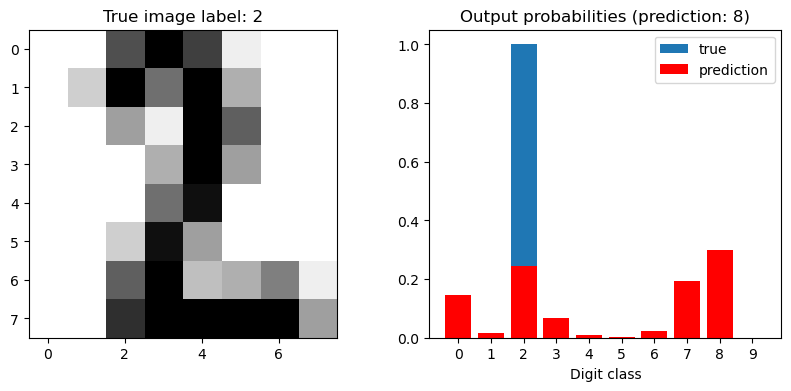

In [18]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    # model: the trained logistic regression model.
    # sample_idx: index of the sample in X_test to visualize.
    # classes: list of class labels.

    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    # creates a figure with two side-by-side plots, ax0 and ax1.
    # figsize=(10, 4) sets the width and height of the figure.

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8), cmap=plt.cm.gray_r, interpolation='nearest')
    # reshapes the test sample into an 8*8 image, and displays it in grayscale.

    ax0.set_title("True image label: %d" % y_test[sample_idx]);
    # sets the title to show the ture label of the image.

    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    # plots a bar chart of the true label as a one-hot vector.

    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    # Plots the predicted probabilities from the model in red.

    ax1.set_xticks(classes)
    # sets the x-axis ticks to match the class labels.

    prediction = model.predict(X_test[sample_idx])
    # gets the predicted class from the model.

    ax1.set_title('Output probabilities (prediction: %d)' % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [19]:
# Create a new logistic regression model
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)
# input_size: number of features per sample from X_train
# output_size: number of classess

learning_rate = 0.01
# Sets the step size for gradient descent.
# Controls how much the weights and biases are updated during training.

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b

    y_pred = lr.forward(x)
    # Computes predicted probabilities for the current sample using softmax.

    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)
    # Computes gradients of the loss regarding weights and biases using the difference between prediction and truth.

    # Update the weights and biases. Applies gradient descent to adjust weights and biases to reduce the loss.
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))

Average NLL over the last 100 samples at step 100: 2
Average NLL over the last 100 samples at step 200: 3
Average NLL over the last 100 samples at step 300: 3
Average NLL over the last 100 samples at step 400: 1
Average NLL over the last 100 samples at step 500: 2
Average NLL over the last 100 samples at step 600: 1
Average NLL over the last 100 samples at step 700: 1
Average NLL over the last 100 samples at step 800: 1
Average NLL over the last 100 samples at step 900: 1
Average NLL over the last 100 samples at step 1000: 2
Average NLL over the last 100 samples at step 1100: 1
Average NLL over the last 100 samples at step 1200: 2
Average NLL over the last 100 samples at step 1300: 2
Average NLL over the last 100 samples at step 1400: 1
Average NLL over the last 100 samples at step 1500: 1


Evaluate the trained model on the first example:

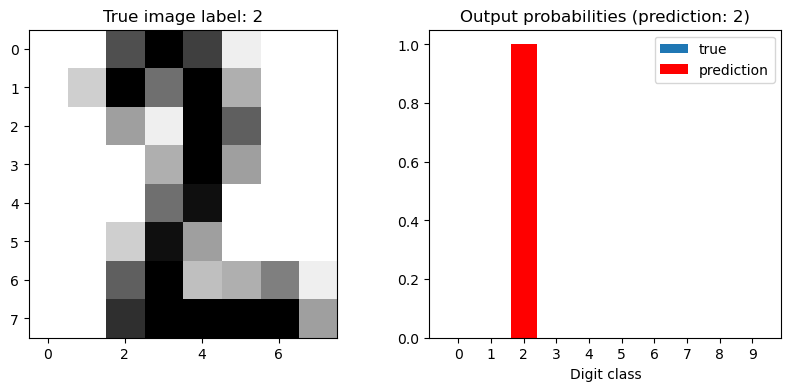

In [20]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

> CYC notes:<br>
> Forward pass >>> Loss calculation >>> Backpropagation >>> Weight update (SGD).

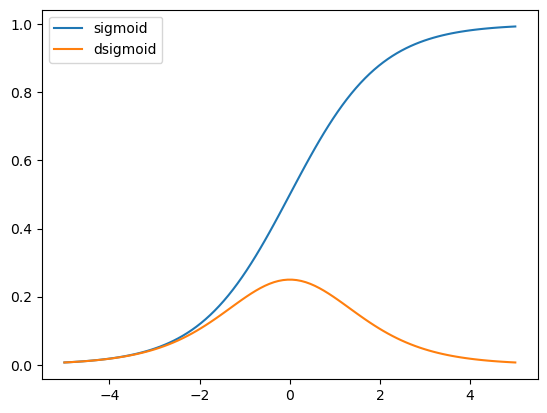

In [21]:
# takes any real number and squashes it into a value between 0 and 1.
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    return 1 / (1 + np.exp(-X)) # Actual sigmoid formula

# derivative of the sigmoid function: tells how sensitive the sigmoid output is to changes in input (crucial for backpropagation)
def dsigmoid(X):
    s = sigmoid(X)
    return s * (1 - s) # Derivative of sigmoid


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

> CYC notes:<br>
> A Multilayer Perceptron (MLP) with one hidden layer and sigmoid activation.<br>
> Step 1: Takes an input vector (image feature).<br>
> Step 2: Passes it through a hidden layer with sigmoid activation.<br>
> Step 3: Outputs a prediction (digit class).<br>
> Step 4: Learns by adjusting weights using backpropagation and gradient descent.<br>

In [22]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
    # Sets up the structure of the networks.

        # Initializes the weights with random numbers

        self.W_h = np.random.uniform(size=(input_size, hidden_size), high=0.1, low=-0.1)
        # W_h: weights connecting input to hidden layers.

        self.b_h = np.random.uniform(size=hidden_size, high=0.1, low=-0.1)
        # b_h: biases for hidden layer neurons.

        self.W_o = np.random.uniform(size=(hidden_size, output_size), high=0.1, low=-0.1)
        # W_o: weights connecting hidden layer to output layer.

        self.b_o = np.random.uniform(size=output_size, high=0.1, low=-0.1)
        # b_o: biases for output layer neurons.


        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    # Hidden Layer Activation: computes the weighted sum of inputs, applies the sigmoid activation to introduce non-linearity.
    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = np.dot(X, self.W_h) + self.b_h
    
        # Apply the sigmoid activation function
        return sigmoid(self.Z_h)

    # Output Layer Activation: Takes hidden layer output H, computes final output scores and applies sigmoid again. 
    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H, self.W_o) + self.b_o

        # Apply the sigmoid activation function
        return sigmoid(self.Z_o)

    # Combines both layers to produce final predictions.
    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)

        return Y

    # Negative Log Likelihood: Converts labels to one-hot format, compute NLL (penalize low confidence in correct class), averages over the batch.
    def loss(self, X, y):
        y = y.astype(int)
        y_pred = self.forward(X)
        y_onehot = one_hot(self.output_size, y)
        log_likelihood = -np.sum(y_onehot * np.log(y_pred + 1e-9))
        return log_likelihood / X.shape[0]

    # Backpropagation: Calculates how to adjust weights to reduce the loss.
    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer: difference between prediction and truth.
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o: Gradients for output weights and biases.
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer: Error at hidden layer, scaled by derivative of sigmoid.
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h: Gradients for hidden weights and biases.
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    # Weight update
    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h -= learning_rate * grads["W_h"] # Updates weights and biases using gradient descent
        self.b_h -= learning_rate * grads["b_h"] # Updates weights and biases using gradient descent
        self.W_o -= learning_rate * grads["W_o"] # Updates weights and biases using gradient descent
        self.b_o -= learning_rate * grads["b_o"] # Updates weights and biases using gradient descent
        
    # Class Prediction: Returns the most likely class for each input.    
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
    
    # Model Evaluation
    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [23]:
n_hidden = 10 # Specifying that the hidden layer should have 10 neurons.
model = NeuralNet(n_features, n_hidden, n_classes)

In [24]:
# Calculate the average loss over your entire training dataset.
model.loss(X_train, y_train)

np.float64(0.7222697328551263)

In [25]:
model.accuracy(X_train, y_train)

np.float64(0.0962671905697446)

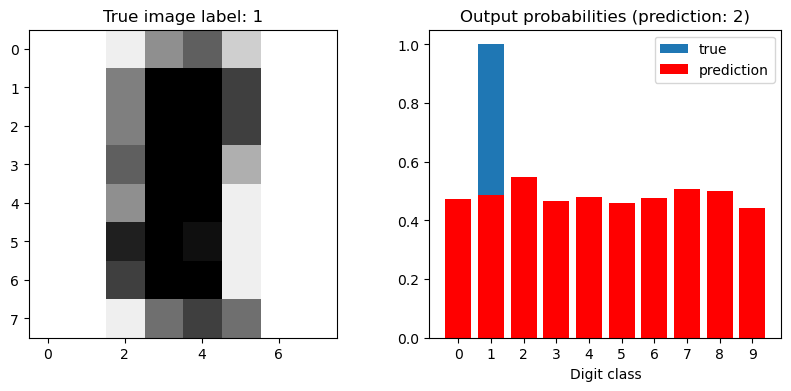

In [26]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [27]:
# These lists will store the training loss, training accuracy, and test accuracy after each epoch.
losses, accuracies, accuracies_test = [], [], []

# Before training begins, record the model's performance with randomly initialized weights.
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

# Prints the initial metrics so can compare them to later epochs.
print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f" % (losses[-1], accuracies[-1], accuracies_test[-1]))

# Training Loop
for epoch in range(15):
# go through the entire training set 15 times.
 
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)
        # Run a forward pass
        # Compute gradients using backpropagation
        # Update weights using a learning rate of 0.001

# Tracking Progress
    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 0.72227, train acc: 0.096, test acc: 0.104
Epoch #1, train loss: 2.19759, train acc: 0.109, test acc: 0.063
Epoch #2, train loss: 2.27211, train acc: 0.109, test acc: 0.063
Epoch #3, train loss: 1.89466, train acc: 0.495, test acc: 0.448
Epoch #4, train loss: 1.68236, train acc: 0.512, test acc: 0.470
Epoch #5, train loss: 1.39912, train acc: 0.536, test acc: 0.493
Epoch #6, train loss: 1.16804, train acc: 0.650, test acc: 0.600
Epoch #7, train loss: 1.04962, train acc: 0.728, test acc: 0.681
Epoch #8, train loss: 0.94003, train acc: 0.768, test acc: 0.726
Epoch #9, train loss: 0.89558, train acc: 0.768, test acc: 0.715
Epoch #10, train loss: 0.78677, train acc: 0.754, test acc: 0.726
Epoch #11, train loss: 0.75789, train acc: 0.747, test acc: 0.711
Epoch #12, train loss: 0.71240, train acc: 0.754, test acc: 0.722
Epoch #13, train loss: 0.77064, train acc: 0.769, test acc: 0.733
Epoch #14, train loss: 0.70096, train acc: 0.787, test acc: 0.756
Epoch #15, train 

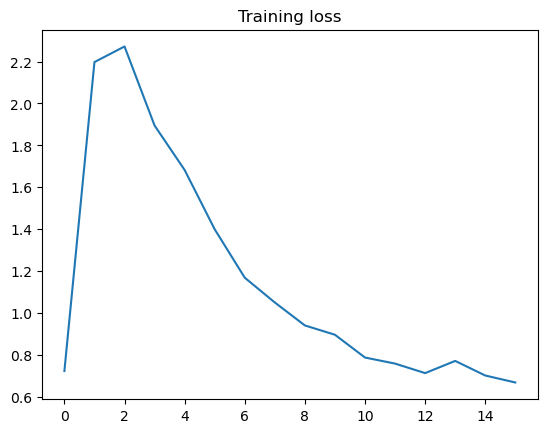

In [28]:
plt.plot(losses)
plt.title("Training loss");

> CYC notes:<br>
> Initial high loss: model starts off with random weights, so it's expected it makes lots of mistakes.<br>
> Slight peak at epoch 1: also expected during early training, unstable gradients.<br>
> Steady decline afterward: showing the model learns well, it's adjusting weights correctly and minimizing error.<br>

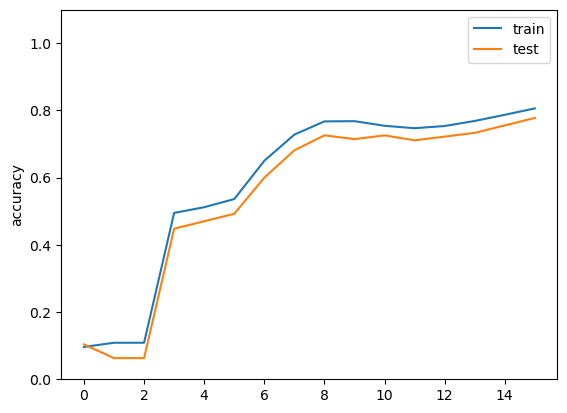

In [29]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

> CYC notes:<br>
> Both training and test accuracy improve quickly in the first few epochs, suggesting the model is learning useful patterns.<br>
> Training accuracy is consistently higher than test accuracy, might be a bit overfitting.<br>
> After a few epochs, both curves start to level off, suggesting the model is getting its performance limit with the current setup.<br>

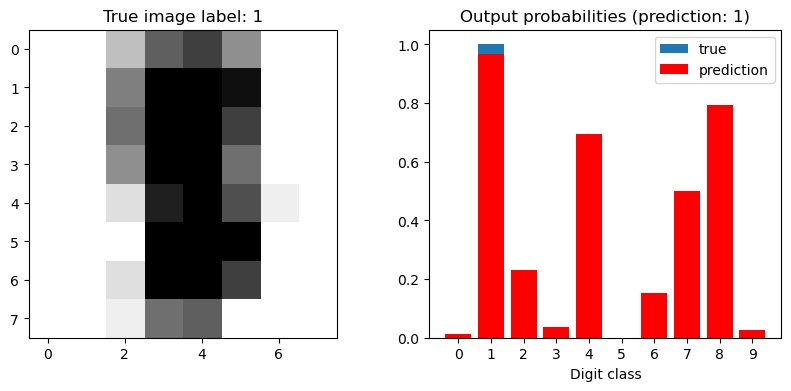

In [30]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

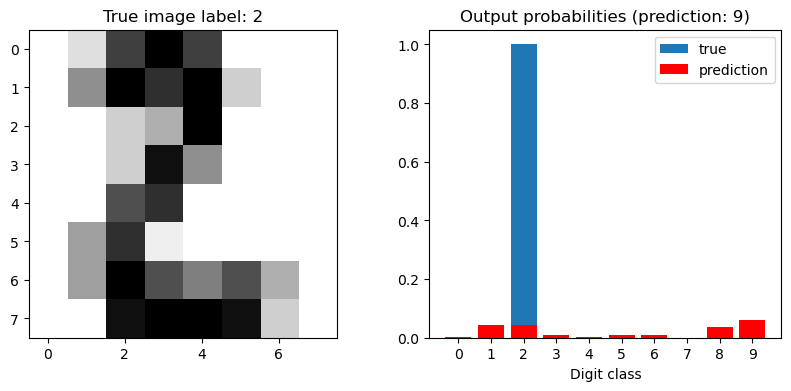

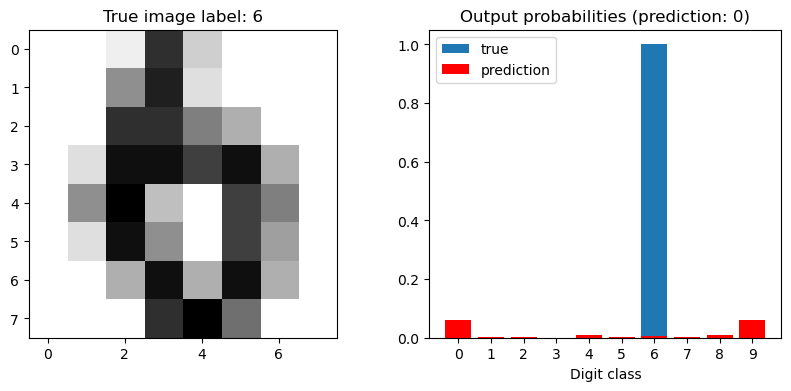

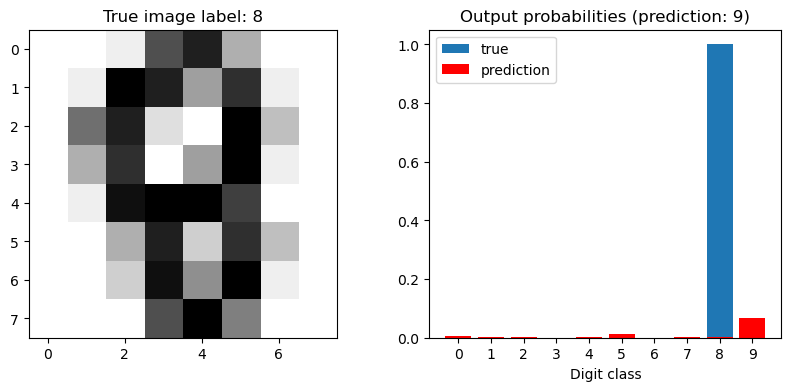

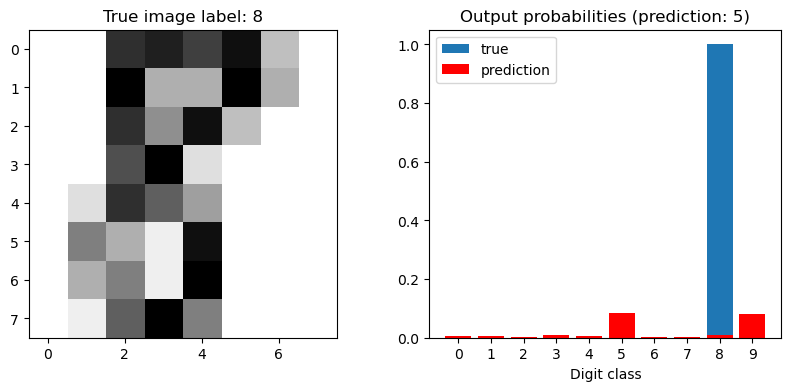

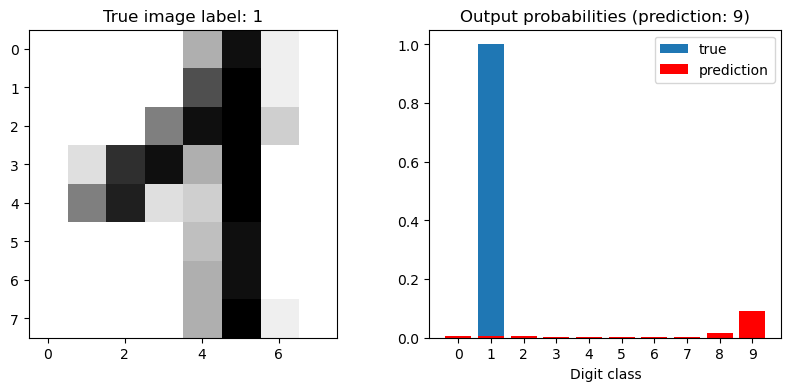

In [31]:
# Identify worst predictions
# Runs the test data through the NN. So y_probs contains predicted probabilities for each digit class for every test sample.
y_probs = model.forward(X_test)

# For each test sample, then determine the digit class with the highest probability.
y_preds = np.argmax(y_probs, axis=1)

# For each prediction, get the probability assigned to the predicted class (tells how confident the model was in its prediction).
confidences = y_probs[np.arange(len(y_test)), y_preds]

# Compare predicted labels to true labels.
unmatch_incorrect = y_preds != y_test

# Sort incorrect predictions by confidence (picks the five least confident wrong predictions).
worst_indices = np.argsort(confidences[unmatch_incorrect])[:5]

# Get original indices of those samples
worst_samples = np.where(unmatch_incorrect)[0][worst_indices]
worst_samples


for i, idx in enumerate(worst_samples):
    plot_prediction(model, sample_idx=idx, classes=range(10))

> CYC notes (would you have done better?):<br>
> Depends on the errors. If it's getting clear digits wrong, that's probably a generalization issue (improve: add more hidden layers, switch from other optimizers, data augmentation).<br> 
>
> But if the digits are ambiguous per se, could try looking at the hidden layer activations to see what the model's actually see or add more discriminative features.<br>

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

> Experiment 1

In [32]:
# Learning rate: 0.001 changed to 0.0005

# These lists will store the training loss, training accuracy, and test accuracy after each epoch.
losses1, accuracies1, accuracies_test1 = [], [], []

# Before training begins, record the model's performance with randomly initialized weights.
losses1.append(model.loss(X_train, y_train)) # model = NeuralNet(n_features, n_hidden, n_classes) from ealier code
accuracies1.append(model.accuracy(X_train, y_train))
accuracies_test1.append(model.accuracy(X_test, y_test))

# Prints the initial metrics so can compare them to later epochs.
print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f" % (losses1[-1], accuracies1[-1], accuracies_test1[-1]))

# Training Loop
for epoch in range(15):
# go through the entire training set 15 times.
 
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.0005)
        # Run a forward pass
        # Compute gradients using backpropagation
        # Update weights using a learning rate of 0.0005

# Tracking Progress
    losses1.append(model.loss(X_train, y_train))
    accuracies1.append(model.accuracy(X_train, y_train))
    accuracies_test1.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses1[-1], accuracies1[-1], accuracies_test1[-1]))

Random init: train loss: 0.66768, train acc: 0.806, test acc: 0.778
Epoch #1, train loss: 0.65379, train acc: 0.829, test acc: 0.796
Epoch #2, train loss: 0.64295, train acc: 0.841, test acc: 0.807
Epoch #3, train loss: 0.64815, train acc: 0.846, test acc: 0.811
Epoch #4, train loss: 0.65299, train acc: 0.857, test acc: 0.837
Epoch #5, train loss: 0.62181, train acc: 0.856, test acc: 0.830
Epoch #6, train loss: 0.62857, train acc: 0.860, test acc: 0.833
Epoch #7, train loss: 0.59859, train acc: 0.870, test acc: 0.848
Epoch #8, train loss: 0.61002, train acc: 0.866, test acc: 0.841
Epoch #9, train loss: 0.57873, train acc: 0.874, test acc: 0.852
Epoch #10, train loss: 0.54662, train acc: 0.883, test acc: 0.874
Epoch #11, train loss: 0.53376, train acc: 0.885, test acc: 0.863
Epoch #12, train loss: 0.54688, train acc: 0.876, test acc: 0.867
Epoch #13, train loss: 0.52048, train acc: 0.884, test acc: 0.870
Epoch #14, train loss: 0.49862, train acc: 0.892, test acc: 0.874
Epoch #15, train 

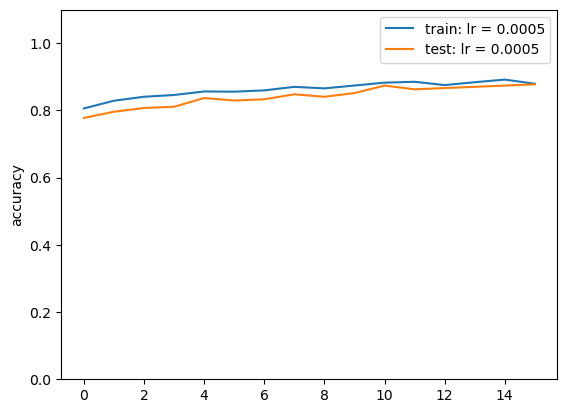

In [33]:
plt.plot(accuracies1, label='train: lr = 0.0005')
plt.plot(accuracies_test1, label='test: lr = 0.0005')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

> Experiment 2

In [34]:
# Size of hidden layer: neurons 10 changed to neurons 30
n_hidden1 = 30 # Specifying that the hidden layer should have 10 neurons.
model1 = NeuralNet(n_features, n_hidden1, n_classes)

# These lists will store the training loss, training accuracy, and test accuracy after each epoch.
losses2, accuracies2, accuracies_test2 = [], [], []

# Before training begins, record the model's performance with randomly initialized weights.
losses2.append(model1.loss(X_train, y_train))
accuracies2.append(model1.accuracy(X_train, y_train))
accuracies_test2.append(model1.accuracy(X_test, y_test))

# Prints the initial metrics so can compare them to later epochs.
print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f" % (losses2[-1], accuracies2[-1], accuracies_test2[-1]))

# Training Loop
for epoch in range(15):
# go through the entire training set 15 times.
 
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model1.train(x, y, 0.001)
        # Run a forward pass
        # Compute gradients using backpropagation
        # Update weights using a learning rate of 0.001

# Tracking Progress
    losses2.append(model1.loss(X_train, y_train))
    accuracies2.append(model1.accuracy(X_train, y_train))
    accuracies_test2.append(model1.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses2[-1], accuracies2[-1], accuracies_test2[-1]))

Random init: train loss: 0.71155, train acc: 0.100, test acc: 0.059
Epoch #1, train loss: 1.45811, train acc: 0.760, test acc: 0.719
Epoch #2, train loss: 0.90039, train acc: 0.849, test acc: 0.841
Epoch #3, train loss: 0.62296, train acc: 0.903, test acc: 0.874
Epoch #4, train loss: 0.47730, train acc: 0.937, test acc: 0.915
Epoch #5, train loss: 0.38905, train acc: 0.955, test acc: 0.933
Epoch #6, train loss: 0.32947, train acc: 0.959, test acc: 0.941
Epoch #7, train loss: 0.28726, train acc: 0.965, test acc: 0.941
Epoch #8, train loss: 0.25662, train acc: 0.969, test acc: 0.944
Epoch #9, train loss: 0.23331, train acc: 0.972, test acc: 0.948
Epoch #10, train loss: 0.21450, train acc: 0.975, test acc: 0.944
Epoch #11, train loss: 0.19876, train acc: 0.978, test acc: 0.944
Epoch #12, train loss: 0.18542, train acc: 0.979, test acc: 0.952
Epoch #13, train loss: 0.17386, train acc: 0.981, test acc: 0.952
Epoch #14, train loss: 0.16357, train acc: 0.982, test acc: 0.952
Epoch #15, train 

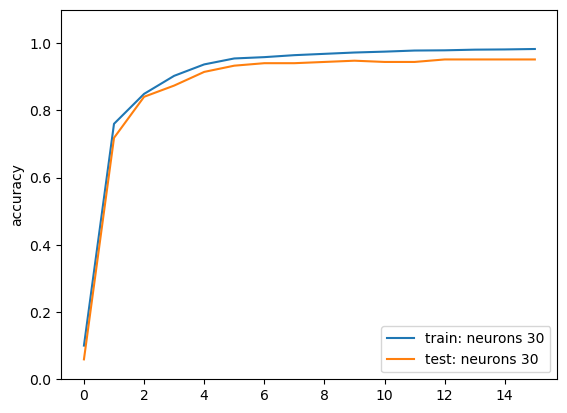

In [35]:
plt.plot(accuracies2, label='train: neurons 30')
plt.plot(accuracies_test2, label='test: neurons 30')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

> Experiment 3

In [36]:
# Add a second hidden layer

class NeuralNet2Hidden():
    """MLP with 2 hidden layers using sigmoid activation"""

    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        self.input_size = input_size
        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.output_size = output_size

        # Layer 1 weights and biases
        self.W_h1 = np.random.uniform(-0.1, 0.1, (input_size, hidden_size1))
        self.b_h1 = np.random.uniform(-0.1, 0.1, hidden_size1)

        # Layer 2 weights and biases
        self.W_h2 = np.random.uniform(-0.1, 0.1, (hidden_size1, hidden_size2))
        self.b_h2 = np.random.uniform(-0.1, 0.1, hidden_size2)

        # Output layer weights and biases
        self.W_o = np.random.uniform(-0.1, 0.1, (hidden_size2, output_size))
        self.b_o = np.random.uniform(-0.1, 0.1, output_size)

    def forward(self, X):
        self.Z_h1 = np.dot(X, self.W_h1) + self.b_h1
        self.H1 = sigmoid(self.Z_h1)

        self.Z_h2 = np.dot(self.H1, self.W_h2) + self.b_h2
        self.H2 = sigmoid(self.Z_h2)

        self.Z_o = np.dot(self.H2, self.W_o) + self.b_o
        return sigmoid(self.Z_o)

    def loss(self, X, y):
        y = y.astype(int)
        y_pred = self.forward(X)
        y_onehot = one_hot(self.output_size, y)
        log_likelihood = -np.sum(y_onehot * np.log(y_pred + 1e-9))
        return log_likelihood / X.shape[0]

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        error_o = y_pred - y_true
        grad_W_o = np.dot(self.H2.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        error_h2 = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h2)
        grad_W_h2 = np.dot(self.H1.T, error_h2)
        grad_b_h2 = np.sum(error_h2, axis=0)

        error_h1 = np.dot(error_h2, self.W_h2.T) * dsigmoid(self.Z_h1)
        grad_W_h1 = np.dot(X.T, error_h1)
        grad_b_h1 = np.sum(error_h1, axis=0)

        return {
            "W_h1": grad_W_h1, "b_h1": grad_b_h1,
            "W_h2": grad_W_h2, "b_h2": grad_b_h2,
            "W_o": grad_W_o, "b_o": grad_b_o
        }

    def train(self, x, y, learning_rate):
        x = x[np.newaxis, :]
        grads = self.grad_loss(x, y)

        self.W_h1 -= learning_rate * grads["W_h1"]
        self.b_h1 -= learning_rate * grads["b_h1"]
        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [37]:
n_hidden2 = 10   
n_hidden3 = 10 
model2 = NeuralNet2Hidden(input_size=n_features, hidden_size1=n_hidden2, hidden_size2=n_hidden3, output_size=n_classes)

# These lists will store the training loss, training accuracy, and test accuracy after each epoch.
losses3, accuracies3, accuracies_test3 = [], [], []

# Before training begins, record the model's performance with randomly initialized weights.
losses3.append(model2.loss(X_train, y_train))
accuracies3.append(model2.accuracy(X_train, y_train))
accuracies_test3.append(model2.accuracy(X_test, y_test))

# Prints the initial metrics so can compare them to later epochs.
print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f" % (losses3[-1], accuracies3[-1], accuracies_test3[-1]))

# Training Loop
for epoch in range(45):
# go through the entire training set 15 times.
 
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model2.train(x, y, 0.005)
        # Run a forward pass
        # Compute gradients using backpropagation
        # Update weights using a learning rate of 0.001

# Tracking Progress
    losses3.append(model2.loss(X_train, y_train))
    accuracies3.append(model2.accuracy(X_train, y_train))
    accuracies_test3.append(model2.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses3[-1], accuracies3[-1], accuracies_test3[-1]))

Random init: train loss: 0.70255, train acc: 0.100, test acc: 0.104
Epoch #1, train loss: 2.29370, train acc: 0.109, test acc: 0.063
Epoch #2, train loss: 2.30249, train acc: 0.109, test acc: 0.063
Epoch #3, train loss: 2.30227, train acc: 0.109, test acc: 0.063
Epoch #4, train loss: 2.30177, train acc: 0.109, test acc: 0.063
Epoch #5, train loss: 2.30084, train acc: 0.109, test acc: 0.063
Epoch #6, train loss: 2.29806, train acc: 0.109, test acc: 0.063
Epoch #7, train loss: 2.29710, train acc: 0.109, test acc: 0.063
Epoch #8, train loss: 2.29522, train acc: 0.109, test acc: 0.063
Epoch #9, train loss: 2.28884, train acc: 0.109, test acc: 0.063
Epoch #10, train loss: 2.27917, train acc: 0.109, test acc: 0.063
Epoch #11, train loss: 2.25783, train acc: 0.183, test acc: 0.137
Epoch #12, train loss: 2.20955, train acc: 0.246, test acc: 0.211
Epoch #13, train loss: 2.13285, train acc: 0.217, test acc: 0.193
Epoch #14, train loss: 2.03366, train acc: 0.213, test acc: 0.189
Epoch #15, train 

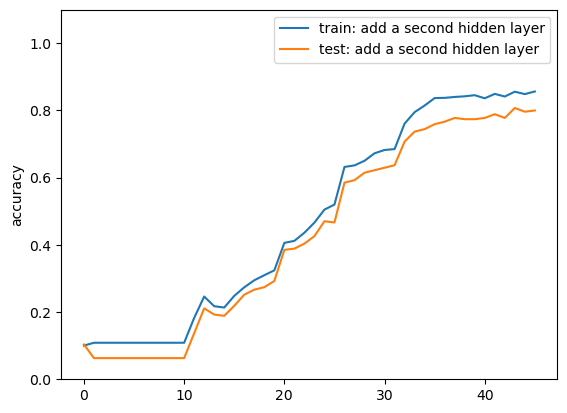

In [38]:
plt.plot(accuracies3, label='train: add a second hidden layer')
plt.plot(accuracies_test3, label='test: add a second hidden layer')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

> CYC notes:<br>
> Based on the experiments I tested, Experiment 2 performs best. There are several possible reasons for this:<br> 
>
> (1) having more neurons increased the model's capacity, allowing it to capture more complex and nuanced relationships in the data;<br>
>
> (2) the learning rate of 0.001 appears to be well balanced. Experiment 1's smaller rate of 0.0005 led to slower learning and underfitting, while Experiment 3's higher rate of 0.005, combined with a deeper network, made its optimization a bit unstable; and<br> 
>
> (3) using a single hidden layer avoid optimization difficulties. Two-layer networks can suffer from vanishing gradients if not properly initialized/normalized.